In [74]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_csv('/content/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


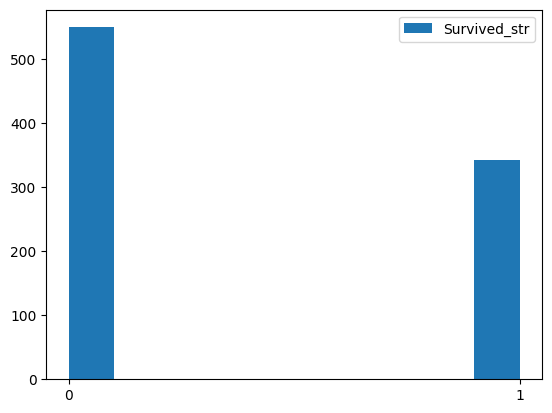

In [26]:
# 1) Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex. Parch - 2 балла
df['Survived_str'] = df['Survived'].astype('str')
df.Survived_str.hist(legend = True, grid = False);

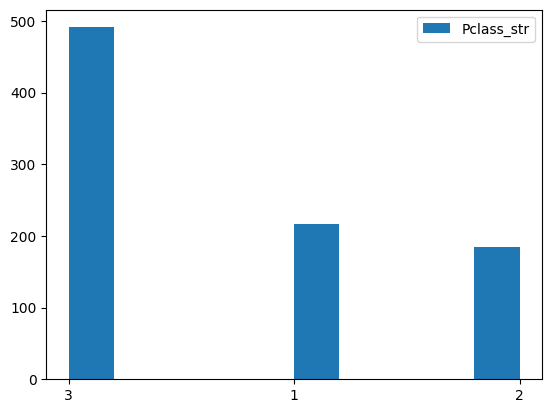

In [25]:
df['Pclass_str'] = df['Pclass'].astype('str')
df.Pclass_str.hist(legend = True, grid = False);

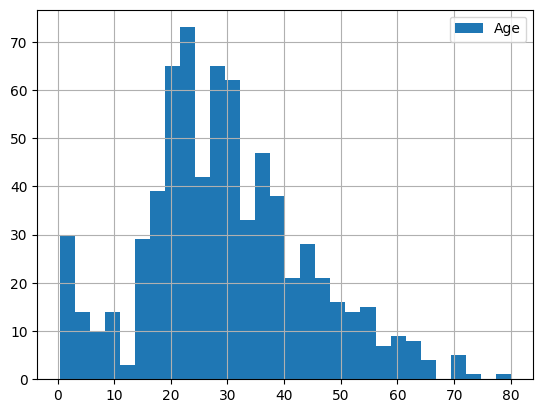

In [20]:
df.Age.hist(legend = True, bins = 30);

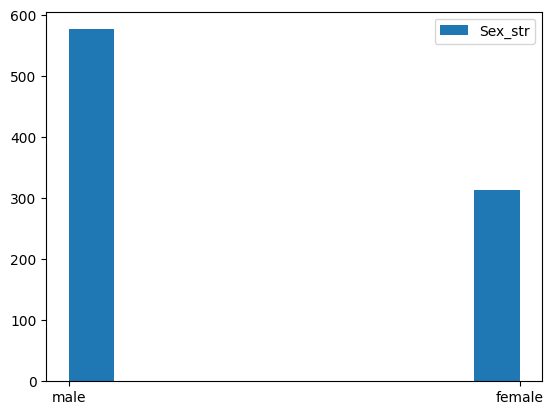

In [28]:
df['Sex_str'] = df['Sex'].astype('str')
df.Sex_str.hist(legend = True, grid = False);

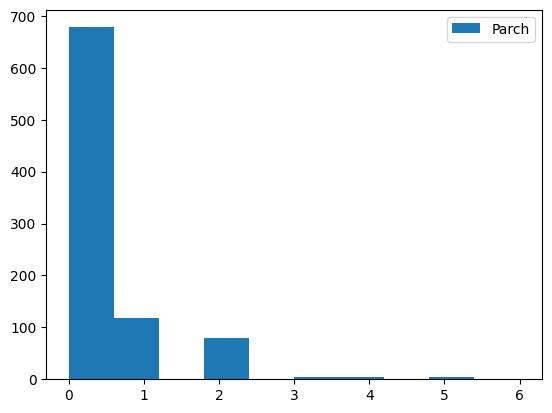

In [34]:
df.Parch.hist(legend = True, grid = False);


Median age: 28.0
Min age   :  0.0 
Max age   : 80.0 
Q1        : 20.125
Q3        : 38.0
IQR       : 17.875
Outliers upper  : 11
Outliers lower  : 0




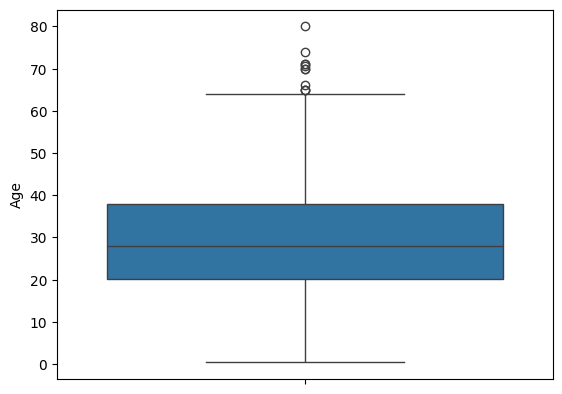

In [65]:
# 2) Постройте график типа boxplot для столбца Age - 1 балл
# 3) Проинтепретируйте полученный график - 1 балл
sns.boxplot(df.Age);

q1 = df.Age.describe().loc['25%']
q3 = df.Age.describe().loc['75%']
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
lower_outliers = df[df.Age < lower_bound]     # Выбросы снизу
upper_outliers = df[df.Age > upper_bound]     # Выбросы сверху 🎯
all_outliers = df[(df.Age < lower_bound) | (df.Age > upper_bound)]


print(f'''
Median age: {df.Age.median()}
Min age   :  {np.round(df.Age.min())}
Max age   : {np.round(df.Age.max())}
Q1        : {q1}
Q3        : {q3}
IQR       : {iqr}
Outliers upper  : {len(upper_outliers)}
Outliers lower  : {len(lower_outliers)}
''')
print('')

In [ ]:
# 4) Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах - 1 балл

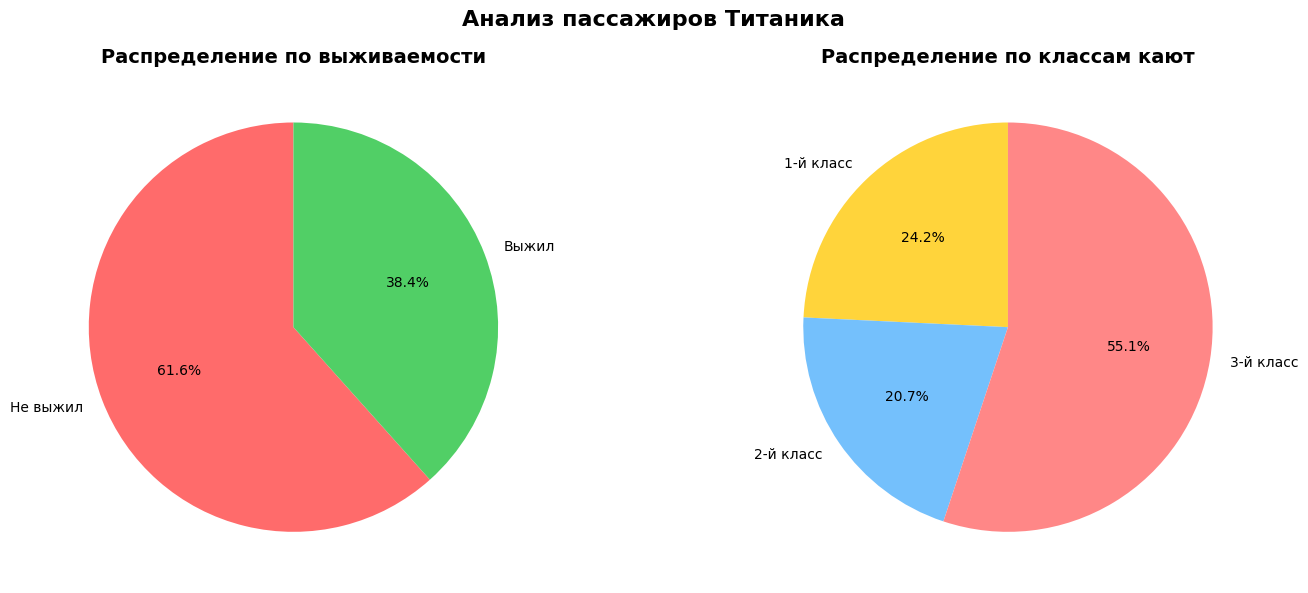

Количество пассажиров по выживаемости:
Survived
0    549
1    342
Name: count, dtype: int64

Количество пассажиров по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [70]:


# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Pie chart для Survived
survived_counts = df['Survived'].value_counts()
labels_survived = ['Не выжил', 'Выжил'] if len(survived_counts) == 2 else ['Не выжил', 'Выжил']
colors_survived = ['#ff6b6b', '#51cf66']

axes[0].pie(survived_counts.values, labels=labels_survived, autopct='%1.1f%%',
            colors=colors_survived, startangle=90)
axes[0].set_title('Распределение по выживаемости', fontsize=14, fontweight='bold')

# 2. Pie chart для Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()
labels_pclass = ['1-й класс', '2-й класс', '3-й класс']
colors_pclass = ['#ffd43b', '#74c0fc', '#ff8787']

axes[1].pie(pclass_counts.values, labels=labels_pclass, autopct='%1.1f%%',
            colors=colors_pclass, startangle=90)
axes[1].set_title('Распределение по классам кают', fontsize=14, fontweight='bold')

# Общие настройки
plt.suptitle('Анализ пассажиров Титаника', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Дополнительная информация
print("Количество пассажиров по выживаемости:")
print(survived_counts)
print("\nКоличество пассажиров по классам:")
print(pclass_counts)

Числовые переменные для pairplot:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


<Figure size 1500x1200 with 0 Axes>

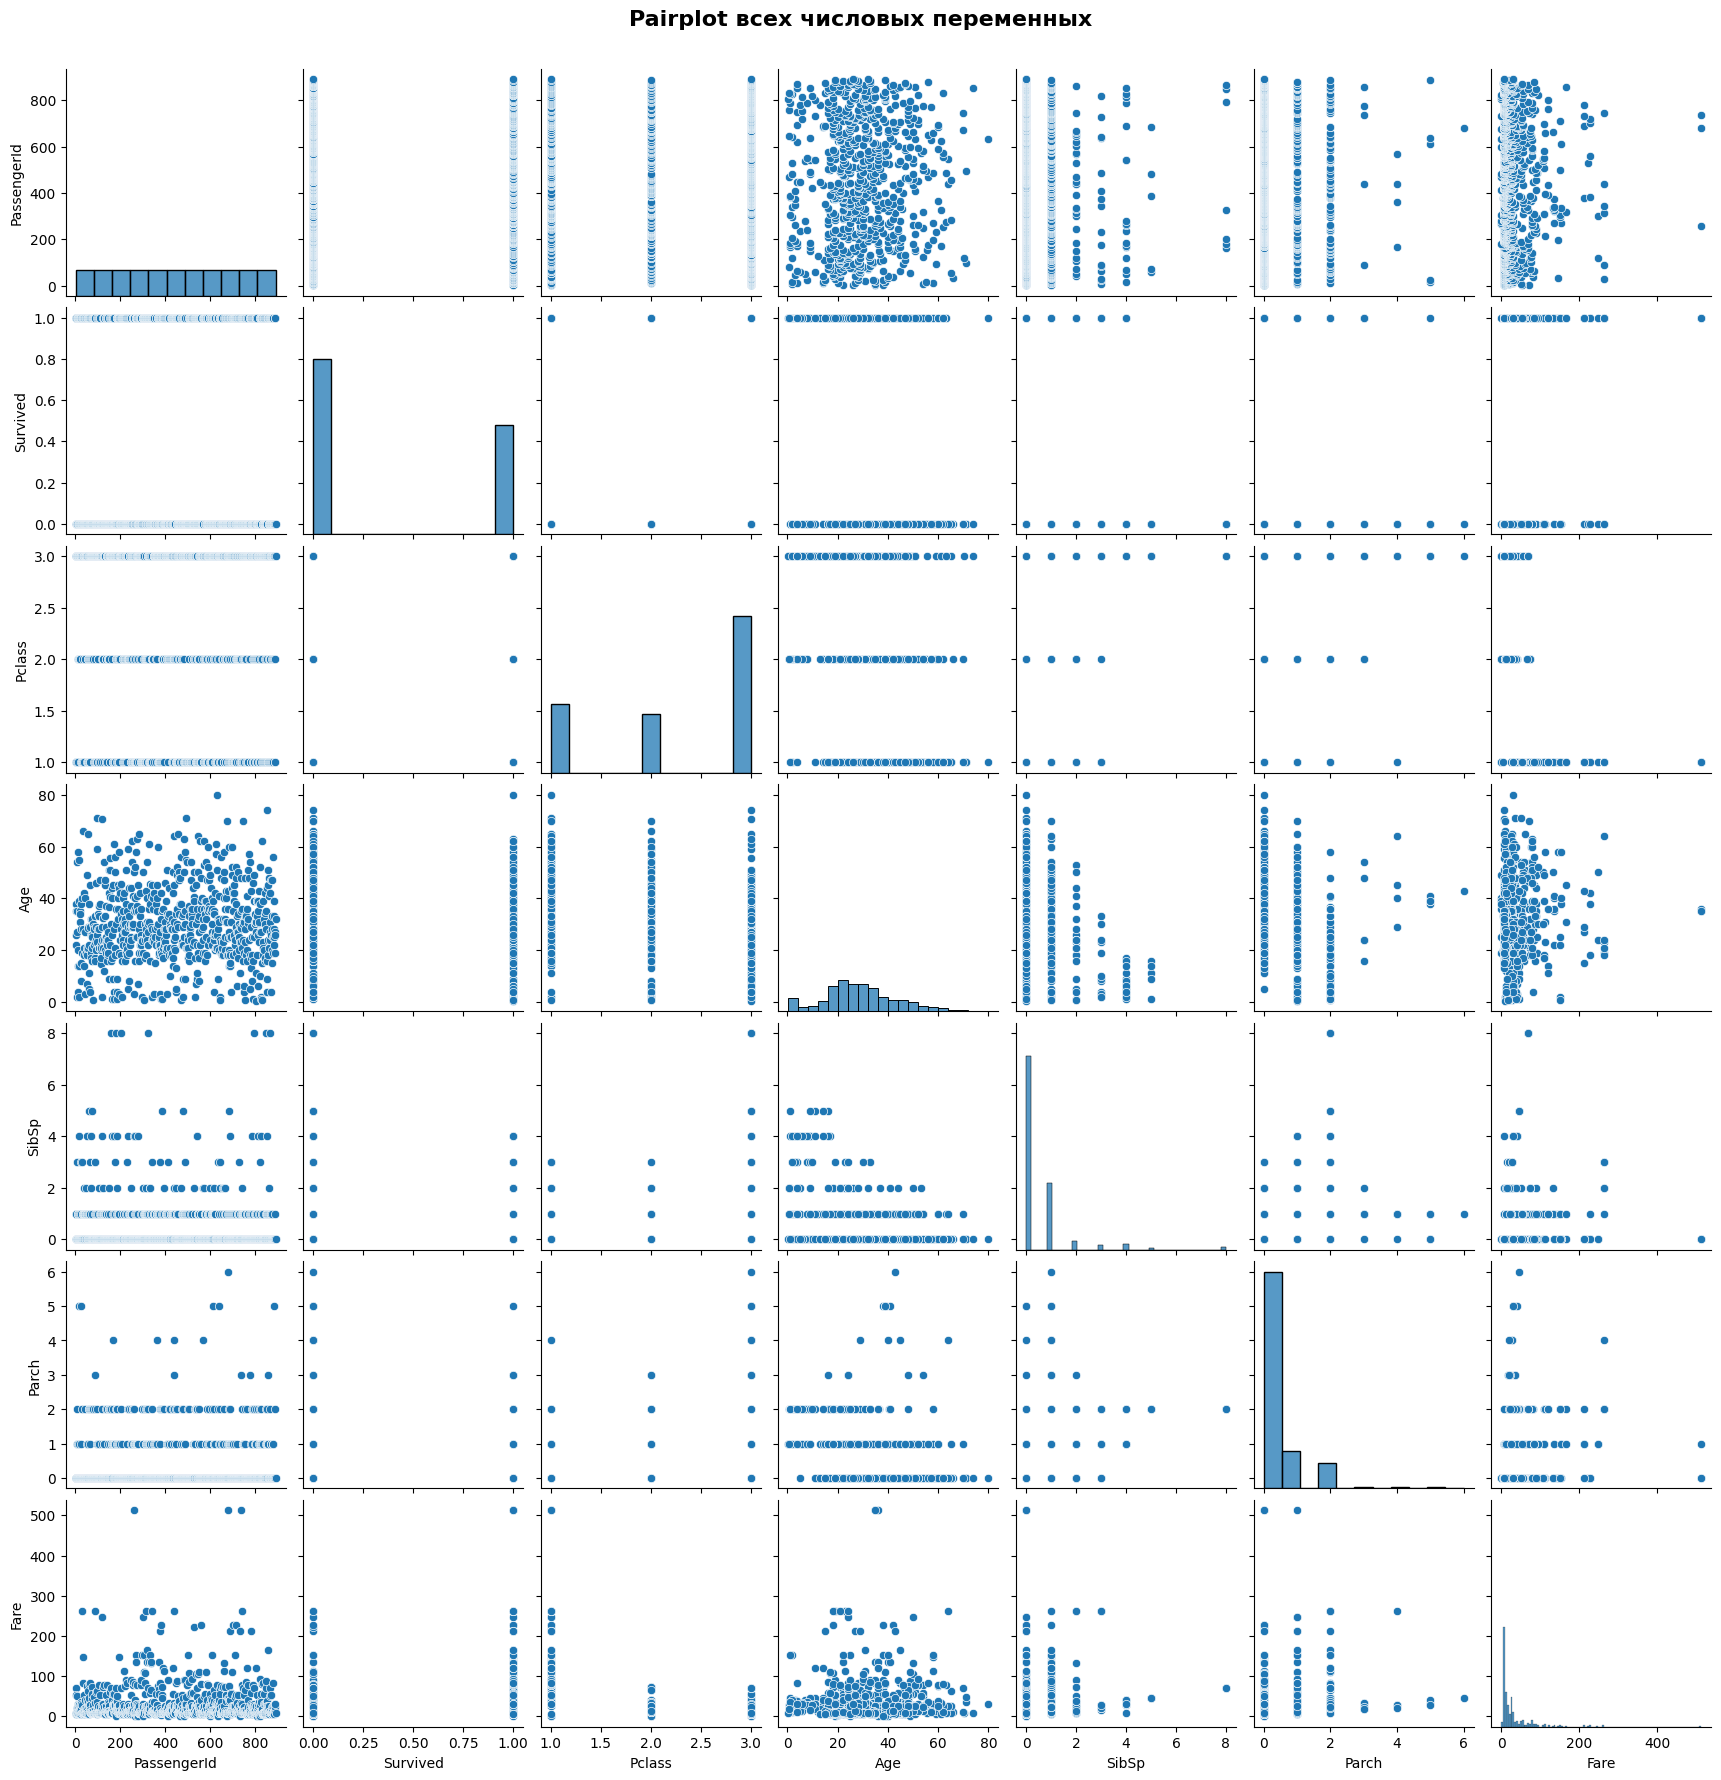

In [72]:
# 5) Постройте график типа pairplot для всех числовых переменных датасета - 1 балл

# Автоматически выбираем только числовые колонки
numeric_columns = df.select_dtypes(include=['number']).columns

print("Числовые переменные для pairplot:")
print(numeric_columns.tolist())

# Строим pairplot
plt.figure(figsize=(15, 12))
sns.pairplot(df[numeric_columns])
plt.suptitle('Pairplot всех числовых переменных', y=1.02, fontsize=16, fontweight='bold')
plt.show();

In [75]:
# 6) Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе - 2 балла

# Создаем данные для sunburst plot
# Группируем по Pclass и Sex, считаем количество пассажиров
sunburst_data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')

# Переименовываем для красивых подписей
sunburst_data['Pclass'] = sunburst_data['Pclass'].map({1: '1-й класс', 2: '2-й класс', 3: '3-й класс'})
sunburst_data['Sex'] = sunburst_data['Sex'].map({'male': 'Мужчины', 'female': 'Женщины'})

# Строим sunburst plot
fig = px.sunburst(
    sunburst_data,
    path=['Pclass', 'Sex'],  # Иерархия: Класс → Пол
    values='count',           # Количество пассажиров
    title='<b>Распределение пассажиров Титаника по классам и полу</b><br>'
          '<sub>Внешнее кольцо - класс кают, внутреннее кольцо - пол</sub>',
    color='Pclass',          # Раскрашиваем по классам
    color_discrete_map={     # Задаем цвета для каждого класса
        '1-й класс': '#FFD700',  # Золотой
        '2-й класс': '#87CEEB',  # Голубой
        '3-й класс': '#FF6B6B'   # Красный
    },
    width=800,
    height=600
)

# Настраиваем внешний вид
fig.update_layout(
    title_x=0.5,
    title_font_size=16,
    font=dict(size=12),
    margin=dict(t=100, l=0, r=0, b=0)
)

# Добавляем подсказки с подробной информацией
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Количество: %{value}<br>Доля от родителя: %{percentParent:.1%}<br>Доля от всего: %{percentRoot:.1%}<extra></extra>'
)

fig.show()

# Дополнительная информация в консоли
print("Данные для sunburst plot:")
print(sunburst_data)
print(f"\nОбщее количество пассажиров: {len(df)}")

Данные для sunburst plot:
      Pclass      Sex  count
0  1-й класс  Женщины     94
1  1-й класс  Мужчины    122
2  2-й класс  Женщины     76
3  2-й класс  Мужчины    108
4  3-й класс  Женщины    144
5  3-й класс  Мужчины    347

Общее количество пассажиров: 891


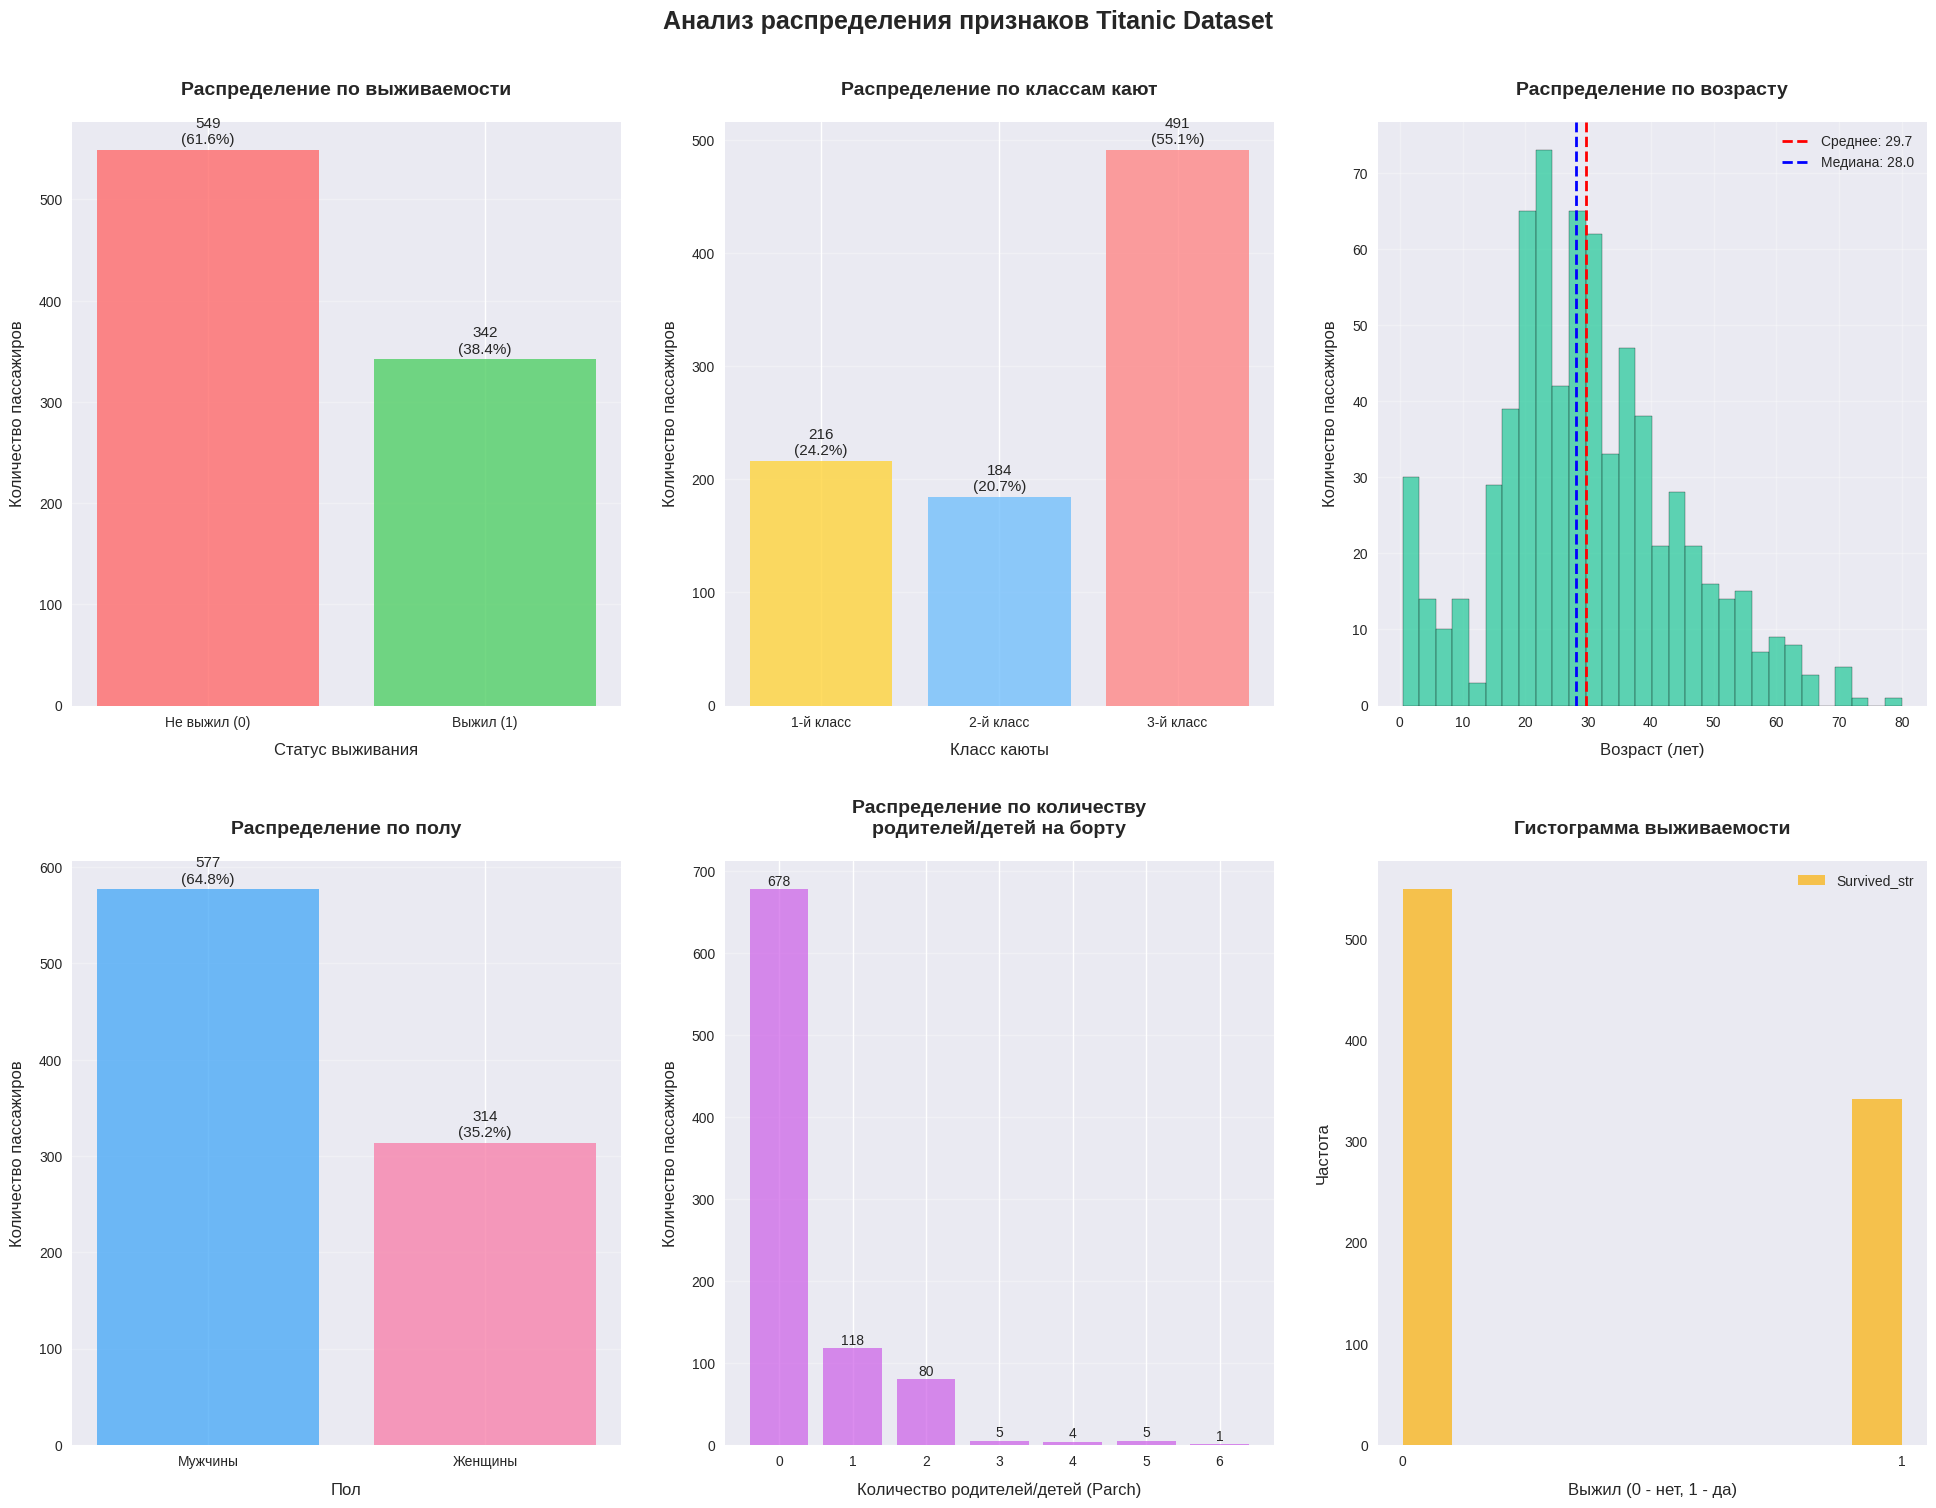

СТАТИСТИКА ПО ПРИЗНАКАМ:
Выживаемость:
Survived
0    549
1    342
Name: count, dtype: int64

Классы кают:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Пол:
Sex
male      577
female    314
Name: count, dtype: int64

Parch (родители/дети):
Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

Возраст - Среднее: 29.7, Медиана: 28.0


In [76]:
# 7) Снабдите все построенные графики наименованиями (title), подписями осей, легендами - 1 балл

# Настройка стиля
plt.style.use('seaborn-v0_8')
fig = plt.figure(figsize=(20, 15))

# 1. Распределение Survived
plt.subplot(2, 3, 1)
survived_counts = df['Survived'].value_counts().sort_index()
bars = plt.bar(['Не выжил (0)', 'Выжил (1)'], survived_counts.values,
               color=['#ff6b6b', '#51cf66'], alpha=0.8)
plt.title('Распределение по выживаемости', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Статус выживания', fontsize=12, labelpad=10)
plt.ylabel('Количество пассажиров', fontsize=12, labelpad=10)
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{height}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# 2. Распределение Pclass
plt.subplot(2, 3, 2)
pclass_counts = df['Pclass'].value_counts().sort_index()
bars = plt.bar(['1-й класс', '2-й класс', '3-й класс'], pclass_counts.values,
               color=['#ffd43b', '#74c0fc', '#ff8787'], alpha=0.8)
plt.title('Распределение по классам кают', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Класс каюты', fontsize=12, labelpad=10)
plt.ylabel('Количество пассажиров', fontsize=12, labelpad=10)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{height}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# 3. Распределение Age
plt.subplot(2, 3, 3)
plt.hist(df['Age'].dropna(), bins=30, color='#20c997', alpha=0.7, edgecolor='black')
plt.title('Распределение по возрасту', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Возраст (лет)', fontsize=12, labelpad=10)
plt.ylabel('Количество пассажиров', fontsize=12, labelpad=10)
plt.grid(alpha=0.3)

# Добавляем статистику
mean_age = df['Age'].mean()
median_age = df['Age'].median()
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_age:.1f}')
plt.axvline(median_age, color='blue', linestyle='--', linewidth=2, label=f'Медиана: {median_age:.1f}')
plt.legend()

# 4. Распределение Sex
plt.subplot(2, 3, 4)
sex_counts = df['Sex'].value_counts()
bars = plt.bar(['Мужчины', 'Женщины'], sex_counts.values,
               color=['#4dabf7', '#f783ac'], alpha=0.8)
plt.title('Распределение по полу', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Пол', fontsize=12, labelpad=10)
plt.ylabel('Количество пассажиров', fontsize=12, labelpad=10)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{height}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# 5. Распределение Parch
plt.subplot(2, 3, 5)
parch_counts = df['Parch'].value_counts().sort_index()
bars = plt.bar([f'{i}' for i in parch_counts.index], parch_counts.values,
               color='#cc5de8', alpha=0.7)
plt.title('Распределение по количеству\nродителей/детей на борту', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Количество родителей/детей (Parch)', fontsize=12, labelpad=10)
plt.ylabel('Количество пассажиров', fontsize=12, labelpad=10)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}',
             ha='center', va='bottom', fontsize=10)

# 6. Дополнительный график - Survived как гистограмма (по вашему примеру)
plt.subplot(2, 3, 6)
df['Survived_str'] = df['Survived'].astype('str')
df['Survived_str'].hist(legend=True, grid=False, color='#fab005', alpha=0.7)
plt.title('Гистограмма выживаемости', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Выжил (0 - нет, 1 - да)', fontsize=12, labelpad=10)
plt.ylabel('Частота', fontsize=12, labelpad=10)
plt.grid(False)

plt.tight_layout(pad=3.0)
plt.suptitle('Анализ распределения признаков Titanic Dataset',
             fontsize=18, fontweight='bold', y=1.02)
plt.show()

# Вывод статистики
print("=" * 60)
print("СТАТИСТИКА ПО ПРИЗНАКАМ:")
print("=" * 60)
print(f"Выживаемость:\n{df['Survived'].value_counts().sort_index()}")
print(f"\nКлассы кают:\n{df['Pclass'].value_counts().sort_index()}")
print(f"\nПол:\n{df['Sex'].value_counts()}")
print(f"\nParch (родители/дети):\n{df['Parch'].value_counts().sort_index()}")
print(f"\nВозраст - Среднее: {df['Age'].mean():.1f}, Медиана: {df['Age'].median():.1f}")